# Load USGS variometer station locations on a map

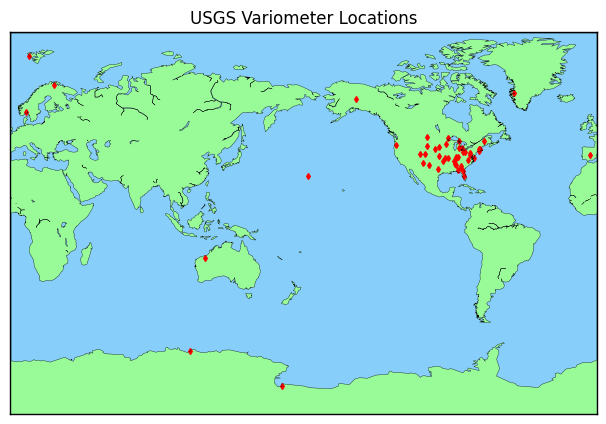

In [1]:
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, tplot_trace_tvars_to_tmap, add_markers, add_station_fovs
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(8,4.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

# mercator/2D map 
tmap = tplot_map(llcrnrlon=0,llcrnrlat=-85,urcrnrlon=360,urcrnrlat=85,projection='mill')
tmap._params.drawmapboundary = {"fill_color":"lightskyblue"}
tmap._params.fillcontinents = {"color":"palegreen","lake_color":"lightskyblue"}

# Add ground station markers
themis_gmag_dict = gmag.Themis_gmag()
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=3)

tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
#date_str = '2026-02-03'
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 15:00:00",'%Y-%m-%d %H:%M:%S'))
plt.title("USGS Variometer Locations")
#ax.legend()
plt.show()

# Plot trace footpaths alongside variometer station markers 

Import packages:

In [2]:
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, tplot_trace_tvars_to_tmap, add_markers, add_station_fovs, tvar_to_foottracks, add_tracks
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

Create tplot variables THEMIS A and THEMIS D positional data:

In [3]:
date_str = '2026-01-19'
time_range = [date_str,date_str]
state(trange=time_range, probe='a')
state(trange=time_range, probe='d')

30-Jun-26 18:22:38: File is current: themis_data/tha/l1/state/2026/tha_l1_state_20260119.cdf
30-Jun-26 18:22:39: File is current: themis_data/thd/l1/state/2026/thd_l1_state_20260119.cdf


['thd_pos',
 'thd_vel',
 'thd_spin_initial_delta_phi',
 'thd_spin_idpu_spinper',
 'thd_spin_segflags',
 'thd_spin_ecl_initial_delta_phi',
 'thd_spin_ecl_idpu_spinper',
 'thd_spin_ecl_segflags',
 'thd_pos_gse',
 'thd_pos_gsm',
 'thd_vel_gse',
 'thd_vel_gsm',
 'thd_pos_sel',
 'thd_pos_sse',
 'thd_vel_sel',
 'thd_vel_sse']

Compute traces:

In [4]:
trace_a = tvar_to_foottracks(tvar_to_trace = 'tha_pos_gsm', model_str = "t89", endpoint = "ionosphere-north")
trace_d = tvar_to_foottracks(tvar_to_trace = 'thd_pos_gsm', model_str = "t89", endpoint = "ionosphere-north")

30-Jun-26 18:22:39: The km parameter is deprecated. Please use units_in, foot_out_units, and trace_out_units instead.
30-Jun-26 18:22:39: Setting units_in, foot_out_units, and trace_out_units to 'km'.
30-Jun-26 18:22:39: Setting units for input_var_re
30-Jun-26 18:22:39: get_t89_parameters: No kp, iopt, or parmod data provided, defaulting to iopt=3


Load IGRF coefficients ...


30-Jun-26 18:22:42: Computed 100/1440 traces so far, current trace time 2026-01-19 01:40:00.000000
30-Jun-26 18:22:44: Computed 200/1440 traces so far, current trace time 2026-01-19 03:20:00.000000
30-Jun-26 18:22:47: Computed 300/1440 traces so far, current trace time 2026-01-19 05:00:00.000000
30-Jun-26 18:22:51: Computed 400/1440 traces so far, current trace time 2026-01-19 06:40:00.000000
30-Jun-26 18:22:55: Computed 500/1440 traces so far, current trace time 2026-01-19 08:20:00.000000
30-Jun-26 18:23:01: Computed 600/1440 traces so far, current trace time 2026-01-19 10:00:00.000000
30-Jun-26 18:23:11: Computed 700/1440 traces so far, current trace time 2026-01-19 11:40:00.000000
30-Jun-26 18:23:21: Computed 800/1440 traces so far, current trace time 2026-01-19 13:20:00.000000
30-Jun-26 18:23:31: Computed 900/1440 traces so far, current trace time 2026-01-19 15:00:00.000000
30-Jun-26 18:23:41: Computed 1000/1440 traces so far, current trace time 2026-01-19 16:40:00.000000
30-Jun-26

Initialize THEMIS GMAG dictionary:

In [5]:
themis_gmag_dict = gmag.Themis_gmag()

Determine which variometer stations are closest to the THEMIS A,D footpaths:

In [6]:
def vpolar_to_vcartesian(theta,phi):
    return (np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta))

def geodetic2geocentric(lat_deg,f=(1/298.26)):
    return np.rad2deg(np.arctan((1/(1-f)**2) * np.tan(np.deg2rad(lat_deg))))

def ang_sep(station_dict:dict,trace_data):
    """
    Determine the angular separation between a station and a probe trace (both the station position and probe trace are given in geodetic degrees)
    """
    s_theta = np.deg2rad(90.0-geodetic2geocentric(lat_deg=float(station_dict['lat'])))
    s_phi = np.deg2rad(float(station_dict['lng']))
    s_x, s_y, s_z = vpolar_to_vcartesian(s_theta,s_phi)
    
    t_theta = np.deg2rad(90.0-geodetic2geocentric(lat_deg=trace_data[:,1]))
    t_phi = np.deg2rad(trace_data[:,2])
    t_x, t_y, t_z = vpolar_to_vcartesian(t_theta,t_phi)
    
    ang_sep_arr = np.rad2deg( np.arccos( (s_x*t_x)+(s_y*t_y)+(s_z*t_z) ) )
    return ang_sep_arr

variom_dist_list = []
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        ang_sep_a = ang_sep(station_dict=station_dict,trace_data=trace_a[0])
        ang_sep_d = ang_sep(station_dict=station_dict,trace_data=trace_d[0])
        dist_tuple = (station_dict['ccode'],np.min(ang_sep_a),np.min(ang_sep_d))
        variom_dist_list.append(dist_tuple)

num_listed = 5

print("Top " + str(num_listed) + " closest stations to THEMIS A:")
variom_dist_list.sort(key=lambda distance: distance[1])
for entry in variom_dist_list[0:num_listed]:
    print("Station: " + entry[0] + "; angular separation: %.2f degrees" % entry[1]) 
#print(variom_dist_list)

print("Top " + str(num_listed) + " closest stations to THEMIS D:")
variom_dist_list.sort(key=lambda distance: distance[2])
for entry in variom_dist_list[0:num_listed]:
    print("Station: " + entry[0] + "; angular separation: %.2f degrees" % entry[2])

Top 5 closest stations to THEMIS A:
Station: KEVO; angular separation: 0.07 degrees
Station: COR; angular separation: 0.42 degrees
Station: COLA; angular separation: 2.24 degrees
Station: MIDW; angular separation: 3.52 degrees
Station: DGMT; angular separation: 4.51 degrees
Top 5 closest stations to THEMIS D:
Station: KEVO; angular separation: 0.41 degrees
Station: COLA; angular separation: 1.39 degrees
Station: KONO; angular separation: 4.56 degrees
Station: COR; angular separation: 4.57 degrees
Station: MIDW; angular separation: 9.19 degrees


In [7]:
close_stations = ["KEVO","COLA"]

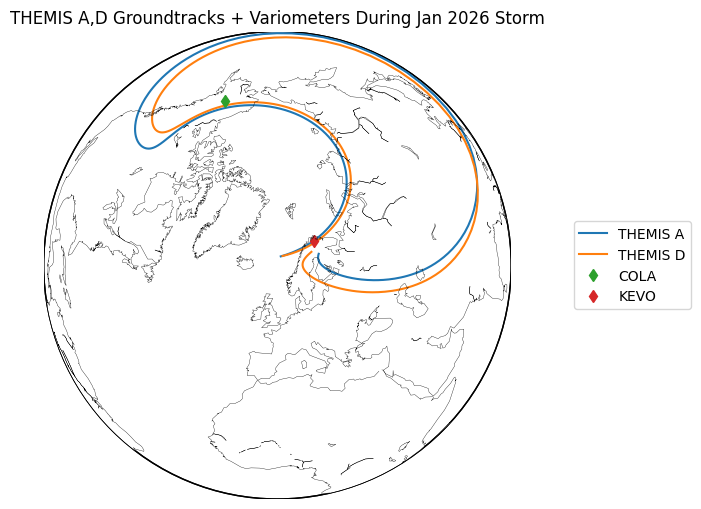

In [8]:
fig=plt.figure(figsize=(8,5.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

mean_lat_a = np.mean((trace_a[0])[:,1])
mean_lon_a = np.mean((trace_a[0])[:,2])
mean_lat_d = np.mean((trace_d[0])[:,1])
mean_lon_d = np.mean((trace_d[0])[:,2])

mean_lat = np.mean([mean_lat_a,mean_lat_d])
mean_lon = np.mean([mean_lon_a,mean_lon_d])

# Initialize map:
#tmap = tplot_map(lat_0=50,lon_0=80)
tmap = tplot_map(lat_0=mean_lat,lon_0=mean_lon)

tmap._params.add_marker = {"linestyle":"","marker":"d"}

# Add ground tracks:
tmap = add_tracks(tmap=tmap, coords=trace_a[0], label = 'THEMIS A')
tmap = add_tracks(tmap=tmap, coords=trace_d[0], label = 'THEMIS D')

station_location_dict = {}

# Add ground station markers
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        if station_dict['ccode'] in close_stations:
            station_location_dict[station_dict['ccode']] = {"lat":float(station_dict['lat']),"lng":float(station_dict['lng'])}
            tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=6)
        
tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 12:00:00",'%Y-%m-%d %H:%M:%S'))

plt.title("THEMIS A,D Groundtracks + Variometers During Jan 2026 Storm")
ax.legend(loc="center right",bbox_to_anchor=(1, 0, 0.4, 1))
plt.show()

Download THEMIS A,D FGM data and KEVO, COLA magnetic field data for the date of the geomagnetic storm:

In [9]:
from pyspedas.projects.themis.spacecraft.fields.fit import fit
from pyspedas.tplot_tools.tplot_names import tplot_names
from pyspedas import subtract_median
fit(trange=time_range,probe='a',get_support_data=True)
fit(trange=time_range,probe='d',get_support_data=True)
gmag.gmag(trange=time_range,sites=["kevo","cola"])
subtract_median(['thg_mag_kevo', 'thg_mag_cola'])
# tplot_names()

30-Jun-26 18:25:46: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/fit/2026/
30-Jun-26 18:25:48: File is current: themis_data/tha/l2/fit/2026/tha_l2_fit_20260119_v01.cdf
30-Jun-26 18:25:48: Unable to get ydata for variable tha_fgs_sigma
30-Jun-26 18:25:48: Variable tha_fgs_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
30-Jun-26 18:25:48: Variable tha_efs_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
30-Jun-26 18:25:48: Variable tha_fit_bfit_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
30-Jun-26 18:25:48: Variable tha_fit_efit_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
30-Jun-26 18:25:48: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thd/l2/fit/2026/
30-Jun-2

['thg_mag_kevo-m', 'thg_mag_cola-m']

Plot magnetic field measurements for THEMIS A, D, COLA, and KEVO in the same time period:

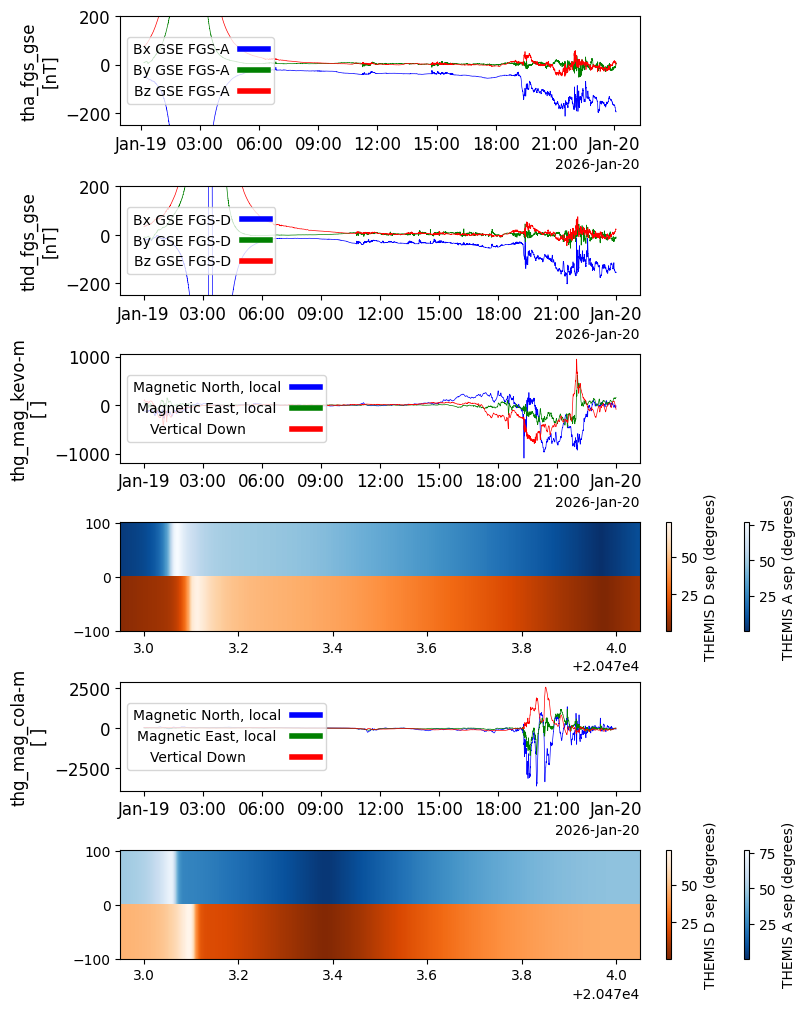

In [10]:
from pyspedas.tplot_tools.MPLPlotter.tplot import tplot
from pyspedas.tplot_tools.get_data import get_data

def v_arr_dupe(y_dim,data):
    Z = np.ones((y_dim,len(data)))
    for i in range(Z.shape[0]):
        Z[i,:]=data
    return Z

fig, axs = plt.subplots(6,layout="constrained",figsize=(8,10))

axs[0].set_ylim(bottom=-250,top=200)
axs[1].set_ylim(bottom=-250,top=200)

ang_sep_kevo_a = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_a[0])
ang_sep_kevo_d = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_d[0])
ang_sep_cola_a = ang_sep(station_dict=station_location_dict["COLA"],trace_data=trace_a[0])
ang_sep_cola_d = ang_sep(station_dict=station_location_dict["COLA"],trace_data=trace_d[0])

t = np.linspace(np.float64(20472.950000578705),np.float64(20474.049987847222),len(get_data("tha_pos_gsm").times))
n_y_pts = 50
ys = np.linspace(get_data('thg_mag_kevo-m').y.min(), get_data('thg_mag_kevo-m').y.max(),n_y_pts)

y_lower = np.linspace(-100, 0,n_y_pts)
y_upper = np.linspace(0, 100,n_y_pts)

Z_KEVO_A = v_arr_dupe(n_y_pts,ang_sep_kevo_a)
Z_KEVO_D = v_arr_dupe(n_y_pts,ang_sep_kevo_d)
Z_COLA_A = v_arr_dupe(n_y_pts,ang_sep_cola_a)
Z_COLA_D = v_arr_dupe(n_y_pts,ang_sep_cola_d)

#X,Y = np.meshgrid(t,ys)
X_L,Y_L = np.meshgrid(t,y_lower)
X_U,Y_U = np.meshgrid(t,y_upper)

a_min = np.min([np.min(Z_KEVO_A),np.min(Z_COLA_A)])
a_max = np.max([np.max(Z_KEVO_A),np.max(Z_COLA_A)])
d_min = np.min([np.min(Z_KEVO_D),np.min(Z_COLA_D)])
d_max = np.max([np.max(Z_KEVO_D),np.max(Z_COLA_D)])

kevo_a_grad = axs[3].pcolormesh(X_U,Y_U,Z_KEVO_A, vmin=a_min, vmax=a_max, shading='auto', cmap="Blues_r", alpha=1)
kevo_d_grad = axs[3].pcolormesh(X_L,Y_L,Z_KEVO_D, vmin=d_min, vmax=d_max, shading='auto', cmap="Oranges_r", alpha=1)
cola_a_grad = axs[5].pcolormesh(X_U,Y_U,Z_COLA_A, vmin=a_min, vmax=a_max, shading='auto', cmap="Blues_r", alpha=1)
cola_d_grad = axs[5].pcolormesh(X_L,Y_L,Z_COLA_D, vmin=d_min, vmax=d_max, shading='auto', cmap="Oranges_r", alpha=1)

fig.colorbar(kevo_a_grad,ax=axs[3],label="THEMIS A sep (degrees)")
fig.colorbar(kevo_d_grad,ax=axs[3],label="THEMIS D sep (degrees)")
fig.colorbar(cola_a_grad,ax=axs[5],label="THEMIS A sep (degrees)")
fig.colorbar(cola_d_grad,ax=axs[5],label="THEMIS D sep (degrees)")

tplot(['tha_fgs_gse','thd_fgs_gse','thg_mag_kevo-m','thg_mag_cola-m'],fig=fig,axis=[axs[0],axs[1],axs[2],axs[4]],pseudo_yaxis_options={'legend_location':'center left'})

#fig.tight_layout()

In [11]:
import matplotlib.dates as mdates

print(get_data("tha_pos_gsm").times)
print((get_data("tha_pos_gsm").times)[0])
print(mdates.num2date((get_data("tha_pos_gsm").times)/(3600*24)))



[1.76878080e+09 1.76878086e+09 1.76878092e+09 ... 1.76886702e+09
 1.76886708e+09 1.76886714e+09]
1768780800.0
[datetime.datetime(2026, 1, 19, 0, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 1, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 2, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 3, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 4, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 5, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 6, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 7, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 9, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 10, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 11, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 1, 19, 0, 12, tzinfo=datetime.timezone.utc), da

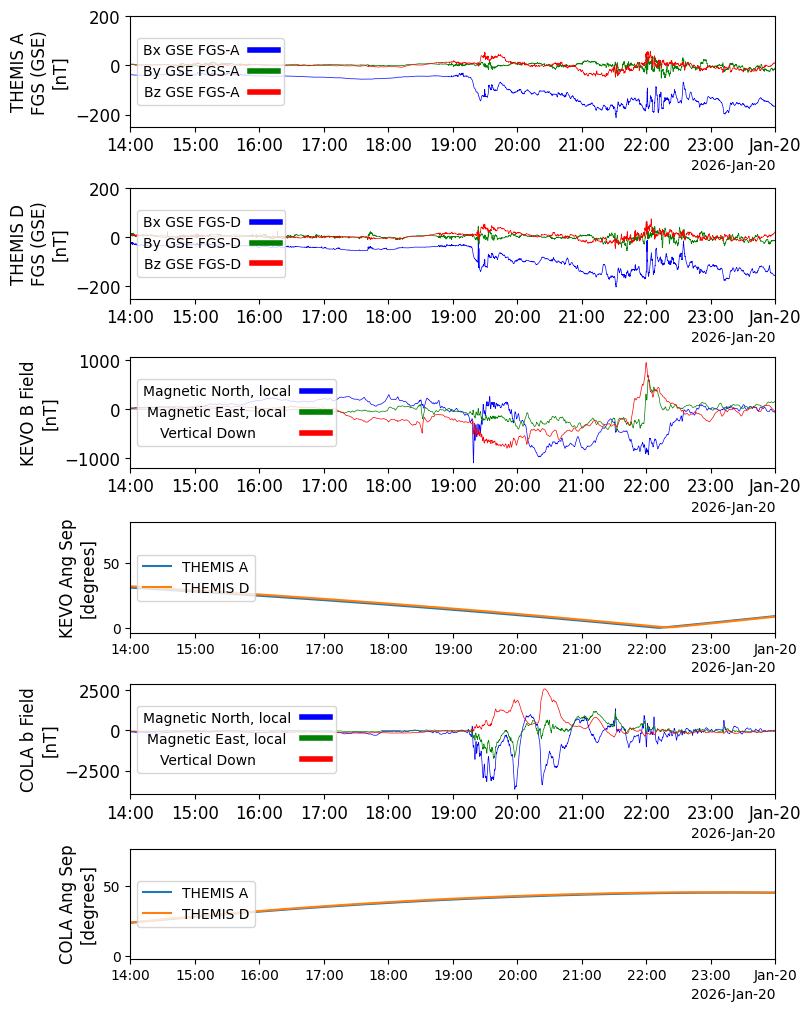

30-Jun-26 18:27:50: C:\Users\DC\AppData\Local\Temp\ipykernel_3696\2439040514.py:46: UserWarning: The figure layout has changed to tight
  fig.tight_layout()



In [ ]:
import pyspedas
from pyspedas.tplot_tools.MPLPlotter.tplot import tplot
from pyspedas.tplot_tools.get_data import get_data
import matplotlib.dates as mdates

fig, axs = plt.subplots(6,layout="constrained",figsize=(8,10))

ang_sep_kevo_a = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_a[0])
ang_sep_kevo_d = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_d[0])
ang_sep_cola_a = ang_sep(station_dict=station_location_dict["COLA"],trace_data=trace_a[0])
ang_sep_cola_d = ang_sep(station_dict=station_location_dict["COLA"],trace_data=trace_d[0])

for ax in axs:
    ax.set_xlim([dt.datetime(2026, 1, 19, 14, 0, tzinfo=dt.timezone.utc),dt.datetime(2026, 1, 20, 0, 0, tzinfo=dt.timezone.utc)])
axs[0].set_ylim(bottom=-250,top=200)
axs[1].set_ylim(bottom=-250,top=200)

axs[3].set_ylabel(f"KEVO Ang Sep\n[degrees]",fontsize=12)
axs[3].tick_params(axis='both', which='major', labelsize=12)
axs[5].set_ylabel(f"COLA Ang Sep\n[degrees]",fontsize=12)
axs[5].tick_params(axis='both', which='major', labelsize=12)

axs[3].plot(mdates.num2date((get_data("tha_pos_gsm").times)/(3600*24)),ang_sep_kevo_a,label="THEMIS A")
axs[3].plot(mdates.num2date((get_data("thd_pos_gsm").times)/(3600*24)),ang_sep_kevo_d,label="THEMIS D")
axs[5].plot(mdates.num2date((get_data("tha_pos_gsm").times)/(3600*24)),ang_sep_cola_a,label="THEMIS A")
axs[5].plot(mdates.num2date((get_data("thd_pos_gsm").times)/(3600*24)),ang_sep_cola_d,label="THEMIS D")

axs[3].legend(loc="center left")
axs[5].legend(loc="center left")

pyspedas.options("tha_fgs_gse", opt_dict={'ytitle':'THEMIS A\nFGS (GSE)'})
pyspedas.options("thd_fgs_gse", opt_dict={'ytitle':'THEMIS D\nFGS (GSE)'})
pyspedas.options("thg_mag_kevo-m", opt_dict={'ytitle':'KEVO B Field','ysubtitle':'[nT]'})
pyspedas.options("thg_mag_cola-m", opt_dict={'ytitle':'COLA b Field','ysubtitle':'[nT]'})

fig,axs = tplot(
    ['tha_fgs_gse','thd_fgs_gse','thg_mag_kevo-m','thg_mag_cola-m'],
    fig=fig,axis=[axs[0],axs[1],axs[2],axs[4]],
    return_plot_objects=True,
    pseudo_yaxis_options={'legend_location':'center left'},)

fig.tight_layout()